# Brownie Cooking Simulator

In this simulation, I attempt to calculate optimal cook times for brownies in pans of various shapes. I approximate the brownie material as a 3D grid of points, with temperature as a scalar field that diffuses through the material via the heat equation. I calibrate the simulation by setting $\alpha$ such that the cook time matches the recipe in the suggested pan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import glob
import subprocess
import os

First, defining some helper functions:

In [7]:
def average_temp(pan_temp):

    return np.mean(pan_temp.flatten())

def min_temp(pan_temp):

    temps = pan_temp.flatten()
    return np.min(temps)

def surface_area(shape):

    return 2 * (shape[0]*shape[1] + shape[1]*shape[2] + shape[2]*shape[0])

## Simulation

This is the numerical solver for the heat equation. Units used are, most confusingly, inches, Kelvin, and minutes.

In [32]:
def simulate(shape, divisions=4, initial_temp=293, oven_temp=450, target_temp=370, dt=0.1, alpha=4e-3):

    arr_shape = np.array([int(shape[i]*divisions) for i in range(3)])
    pan_temp = initial_temp * np.ones(shape=arr_shape)
    elapsed = 0
    timesteps = []
    timesteps.append(pan_temp)

    while min_temp(pan_temp) < target_temp:
        updated_pan_temp = np.zeros_like(pan_temp)

        for x in range(arr_shape[0]):
            for y in range(arr_shape[1]):
                for z in range(arr_shape[2]):

                    T = pan_temp[x, y, z]
                    Tx0 = pan_temp[x-1, y, z] if x != 0 else oven_temp
                    Tx1 = pan_temp[x+1, y, z] if x != arr_shape[0]-1 else oven_temp
                    Ty0 = pan_temp[x, y-1, z] if y != 0 else oven_temp
                    Ty1 = pan_temp[x, y+1, z] if y != arr_shape[1]-1 else oven_temp
                    Tz0 = pan_temp[x, y, z-1] if z != 0 else oven_temp
                    Tz1 = pan_temp[x, y, z+1] if z != arr_shape[2]-1 else oven_temp

                    dx = 1 / divisions
                    laplacian = (Tx1 + Tx0 + Ty1 + Ty0 + Tz1 + Tz0 - 6*T) / dx**2

                    dT = alpha * laplacian * dt
                    updated_pan_temp[x, y, z] = T + dT

        timesteps.append(updated_pan_temp)
        pan_temp = updated_pan_temp
        elapsed += dt

    return tuple(timesteps)

In [33]:
shapes = np.array([
    (8, 8, 1),
    (8, 4, 2),
    (4, 4, 4),
])

sims = [simulate(shape) for shape in shapes]

## Visualization

Now we can plot our results, visualizing the average and minimum internal temperatures as the simulation progresses.

Text(0.5, 1.0, 'Average Internal Temperature')

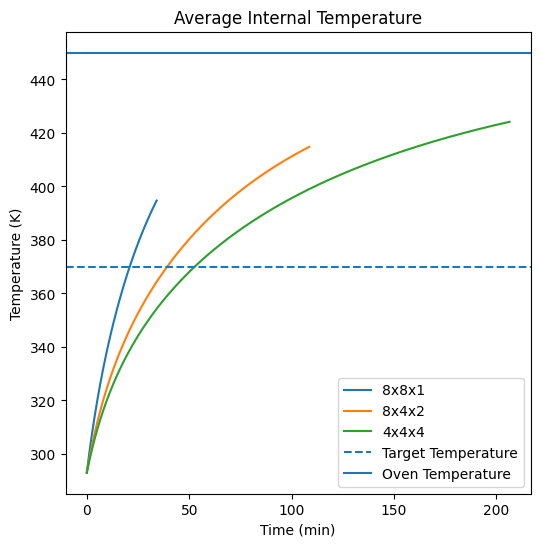

In [42]:
fig, ax = plt.subplots(figsize=(6, 6))

for i, timesteps in enumerate(sims):
    elapsed = len(timesteps) * 0.1
    time = np.linspace(0, elapsed, len(timesteps))
    temps = [average_temp(step) for step in timesteps]
    shape = shapes[i]
    label = str(shape[0]) + "x" + str(shape[1]) + "x" + str(shape[2])
    ax.plot(time, temps, label=label)

ax.axhline(370, linestyle="--", label="Target Temperature")
ax.axhline(450, linestyle="-", label="Oven Temperature")
ax.legend()
ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Average Internal Temperature")

Text(0.5, 1.0, 'Minimum Internal Temperature')

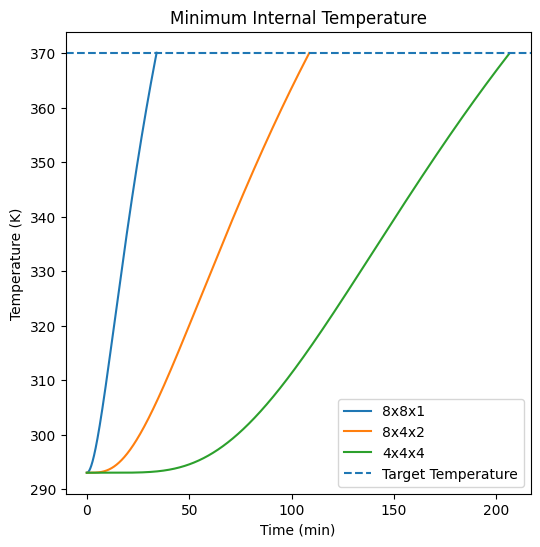

In [44]:
fig, ax = plt.subplots(figsize=(6, 6))

for i, timesteps in enumerate(sims):
    elapsed = len(timesteps) * 0.1
    time = np.linspace(0, elapsed, len(timesteps))
    min_temps = [min_temp(step) for step in timesteps]
    shape = shapes[i]
    label = str(shape[0]) + "x" + str(shape[1]) + "x" + str(shape[2])
    ax.plot(time, min_temps, label=label)

ax.axhline(370, linestyle="--", label="Target Temperature")
ax.legend()
ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Minimum Internal Temperature")

Text(0.5, 1.0, 'Effect of Varying Surface Area on Cook Time')

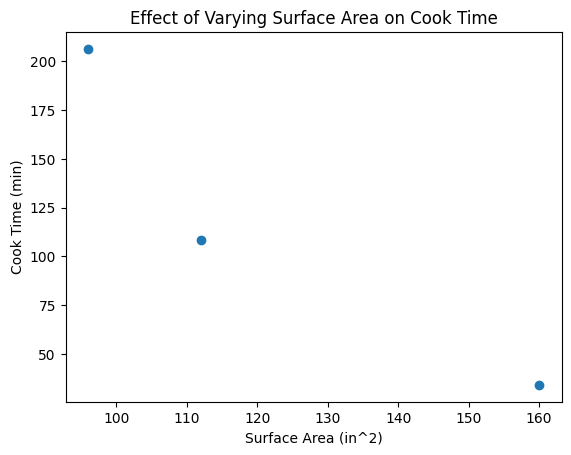

In [41]:
areas = np.array([surface_area(shape) for shape in shapes])
cook_times = np.array([len(sim) for sim in sims]) * 0.1
plt.scatter(areas, cook_times)
plt.xlabel("Surface Area (in^2)")
plt.ylabel("Cook Time (min)")
plt.title("Effect of Varying Surface Area on Cook Time")

Also we can render a heatmap movie showing the internal temperature through any 2D cross-section of the pan. I thought about doing this in 3D, but I think it would be too hard to read, even with some clever opacity stuff.

In [ ]:
sim_n = 1
timesteps = sims[sim_n]
length, width, height = shapes[sim_n]
divisions = 4
arr_shape = np.array([int(divisions*side) for side in shapes[sim_n]])
oven_temp, initial_temp = 450, 293
dt = 0.1

for i, state in enumerate(timesteps):
    fig, ax = plt.subplots(figsize=(length, width))
    z = int(arr_shape[2]/2)
    for x in range(arr_shape[0]):
        for y in range(arr_shape[1]):
            T = state[x, y, z]
            temp_range = oven_temp - initial_temp
            color = ((T - initial_temp)/temp_range, 0, 1 - (T - initial_temp)/temp_range)
            plt.plot(x/divisions, y/divisions, color=color, marker="s", markersize=13)

    ax.set_aspect("equal")
    ax.set_title("Central Cross-Section of Brownies at time = " + str(int(i*dt)) + "min")
    ax.set_xlabel("Length (in)")
    ax.set_ylabel("Width (in)")
    fig.savefig('{steps:04}'.format(steps=i))
    plt.close()

out_filename = str(length) + "x" + str(width) + "x" + str(height)
fps = 30
subprocess.run(["ffmpeg", "-nostdin", "-y", "-framerate", str(fps), "-pattern_type", "glob", "-i", "*.png", "-c:v", "libx264", "-pix_fmt", "yuv420p", out_filename+".mp4"])
for file in glob.glob("*.png"):
    if file[:4].isdigit():
        os.remove(file)

## Sphere?

I think a sphere is probably the worst shape to bake brownies in, so let's test that now.

In [8]:
def point_in_sphere(point, radius, center_radius):

    dist = np.sqrt((point[0] - center_radius)**2 + (point[1] - center_radius)**2 + (point[2] - center_radius)**2)
    return np.round(dist) < radius

def average_temp_sphere(pan_temp, radius, center_radius):

    n_points = 0
    temp_sum = 0

    for x in range(pan_temp.shape[0]):
        for y in range(pan_temp.shape[1]):
            for z in range(pan_temp.shape[2]):
                if point_in_sphere((x, y, z), radius, center_radius):
                    n_points += 1
                    temp_sum += pan_temp[x, y, z]

    return temp_sum / n_points

def min_temp_sphere(pan_temp):

    temps = pan_temp.flatten()
    return np.min(temps)

In [9]:
def simulate_sphere(radius, divisions=4, initial_temp=293, oven_temp=450, target_temp=370, dt=0.1, alpha=4e-3):

    arr_d = 2*int(divisions*radius+1)
    pan_temp = initial_temp * np.ones(shape=(arr_d, arr_d, arr_d))
    elapsed = 0
    timesteps = []

    for x in range(arr_d):
        for y in range(arr_d):
            for z in range(arr_d):
                if not point_in_sphere((x, y, z), (arr_d-2)/2, arr_d/2):
                    pan_temp[x, y, z] = 450

    timesteps.append(pan_temp)

    while min_temp_sphere(pan_temp) < target_temp:
        updated_pan_temp = 450 * np.ones_like(pan_temp)

        for x in range(1, arr_d-1):
            for y in range(1, arr_d-1):
                for z in range(1, arr_d-1):

                    if not point_in_sphere((x, y, z), (arr_d - 2)/2, arr_d/2):
                        continue

                    T = pan_temp[x, y, z]
                    Tx0 = pan_temp[x-1, y, z]
                    Tx1 = pan_temp[x+1, y, z]
                    Ty0 = pan_temp[x, y-1, z]
                    Ty1 = pan_temp[x, y+1, z]
                    Tz0 = pan_temp[x, y, z-1]
                    Tz1 = pan_temp[x, y, z+1]

                    dx = 1 / divisions
                    laplacian = (Tx1 + Tx0 + Ty1 + Ty0 + Tz1 + Tz0 - 6*T) / dx**2

                    dT = alpha * laplacian * dt
                    updated_pan_temp[x, y, z] = T + dT

        timesteps.append(updated_pan_temp)
        pan_temp = updated_pan_temp
        elapsed += dt

    return tuple(timesteps)

In [14]:
radius = (64*3/(4*np.pi)) ** (1/3) + 0.25
sim_sphere = simulate_sphere(radius)

Text(0.5, 1.0, 'Sphere Internal Temperature')

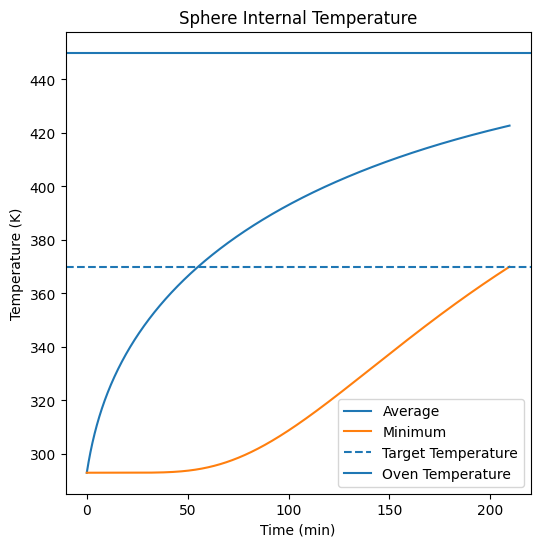

In [15]:
arr_d = 2 * int(4*radius+1)

fig, ax = plt.subplots(figsize=(6, 6))
timesteps = sim_sphere
elapsed = len(timesteps) * 0.1
time = np.linspace(0, elapsed, len(timesteps))
temps = [average_temp_sphere(step, (arr_d - 2)/2, arr_d/2) for step in timesteps]
min_temps = [min_temp_sphere(step) for step in timesteps]
ax.plot(time, temps, label="Average")
ax.plot(time, min_temps, label="Minimum")
ax.plot()

ax.axhline(370, linestyle="--", label="Target Temperature")
ax.axhline(450, linestyle="-", label="Oven Temperature")
ax.legend()
ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Sphere Internal Temperature")

In [16]:
divisions = 4
oven_temp, initial_temp = 450, 293
dt = 0.1

for i, state in enumerate(timesteps):
    fig, ax = plt.subplots(figsize=(2*radius, 2*radius))
    z = int(arr_d/2)
    for x in range(arr_d):
        for y in range(arr_d):
            if not point_in_sphere((x, y, z), (arr_d-2)/2, arr_d/2):
                plt.plot(x/divisions, y/divisions, color="gray", marker="s", markersize=13)
                continue

            T = state[x, y, z]
            temp_range = oven_temp - initial_temp
            color = ((T - initial_temp)/temp_range, 0, 1 - (T - initial_temp)/temp_range)
            plt.plot(x/divisions, y/divisions, color=color, marker="s", markersize=13)

    ax.set_aspect("equal")
    ax.set_title("Central Cross-Section of Brownies at time = " + str(int(i*dt)) + "min")
    ax.set_xlabel("Length (in)")
    ax.set_ylabel("Width (in)")
    fig.savefig('{steps:04}'.format(steps=i))
    plt.close()

In [17]:
out_filename = "sphere"
fps = 30
subprocess.run(["ffmpeg", "-nostdin", "-y", "-framerate", str(fps), "-pattern_type", "glob", "-i", "*.png", "-c:v", "libx264", "-pix_fmt", "yuv420p", out_filename+".mp4"])
for file in glob.glob("*.png"):
    if file[:4].isdigit():
        os.remove(file)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.0.13.3)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_3 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex